In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm.notebook import tqdm
from collections import defaultdict

# --- Configuration ---
# HPATCHES_ROOT = "/home/boat/proxyISP/pytorch-superpoint/datasets/HPatches_s21fe_reordered/"
HPATCHES_ROOT = "/mnt/ssd2tb/boat/thesis/superpoint_dataset/HPatches_original"
H_FILES = ["H_1_2", "H_1_3", "H_1_4", "H_1_5", "H_1_6"]
# SEQ_PREFIXES = ["sl", "wl", "ll"]
SEQ_PREFIXES = ["v_"]

# Utility function to read homography
def read_homography(hpath):
    return np.loadtxt(hpath).reshape(3, 3)

# Store average normalized displacement stats
disp_stats = {hfile: {prefix: {} for prefix in SEQ_PREFIXES} for hfile in H_FILES}

# Main loop
for hfile in tqdm(H_FILES, desc="Processing homography files"):
    seq_list = [seq for seq in os.listdir(HPATCHES_ROOT) if os.path.isdir(os.path.join(HPATCHES_ROOT, seq))]
    for seq in tqdm(seq_list, desc=f"Sequences for {hfile}", leave=False):
        seq_path = os.path.join(HPATCHES_ROOT, seq)
        prefix = next((p for p in SEQ_PREFIXES if seq.startswith(p)), None)
        if prefix is None:
            continue

        # Read image to get size
        img_path = os.path.join(seq_path, "1.ppm")
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to load image: {img_path}")
            continue

        img_height, img_width = img.shape[:2]

        # Generate grid points (x,y) in homogeneous coords (N,3)
        xx, yy = np.meshgrid(np.arange(img_width), np.arange(img_height))
        pts = np.vstack([xx.ravel(), yy.ravel(), np.ones_like(xx).ravel()])  # shape (3, N)

        hpath = os.path.join(seq_path, hfile)
        if not os.path.exists(hpath):
            continue

        try:
            H = read_homography(hpath)
            H = H / H[2, 2]  # Normalize H

            # Apply homography
            pts_transformed = H @ pts
            pts_transformed /= pts_transformed[2, :]

            # Normalized displacement
            dx = (pts_transformed[0, :] - pts[0, :]) / img_width
            dy = (pts_transformed[1, :] - pts[1, :]) / img_height
            dist = np.sqrt(dx**2 + dy**2)

            avg_dist = np.mean(dist)  # Unitless, scale-invariant
            disp_stats[hfile][prefix][seq] = avg_dist

        except Exception as e:
            print(f"Error processing {hpath}: {e}")


Processing homography files:   0%|          | 0/5 [00:00<?, ?it/s]

Sequences for H_1_2:   0%|          | 0/116 [00:00<?, ?it/s]

Sequences for H_1_3:   0%|          | 0/116 [00:00<?, ?it/s]

Sequences for H_1_4:   0%|          | 0/116 [00:00<?, ?it/s]

Sequences for H_1_5:   0%|          | 0/116 [00:00<?, ?it/s]

Sequences for H_1_6:   0%|          | 0/116 [00:00<?, ?it/s]

In [26]:
import numpy as np
import pandas as pd

for prefix in SEQ_PREFIXES:
    records = []
    seqs = list({seq for hfile in H_FILES for seq in disp_stats[hfile][prefix].keys()})
    seqs.sort()

    for seq in seqs:
        row = {"seq_name": seq}
        for hfile in H_FILES:
            row[hfile] = disp_stats[hfile][prefix].get(seq, np.nan)  # Use NaN if missing
        records.append(row)

    df = pd.DataFrame(records)
    print(f"\n=== Normalized Pixel Displacement Table for prefix: {prefix} ===")
    print(df.to_string(index=False))
    df.to_csv(f"hpatches_pixel_disp_{prefix}.csv", index=False)
    print(f"Saved to hpatches_pixel_disp_{prefix}.csv")

    # Compute mean and std dev per H_file
    means = df[H_FILES].mean(skipna=True)
    stds = df[H_FILES].std(skipna=True)

    print(f"\nMean average normalized displacement for prefix '{prefix}':")
    for hfile in H_FILES:
        print(f"  {hfile}: {means[hfile]:.5f} (± {stds[hfile]:.5f})")



=== Normalized Pixel Displacement Table for prefix: v_ ===
     seq_name    H_1_2    H_1_3    H_1_4    H_1_5    H_1_6
   v_abstract 0.093184 0.082625 0.133601 0.207844 0.229178
       v_adam 0.091458 0.116058 0.177143 0.146594 0.152171
v_apprentices 0.053521 0.142229 0.159995 0.201468 0.263110
   v_artisans 0.277768 0.263829 0.216717 6.488906 0.228124
v_astronautis 0.272353 0.300840 0.297461 0.428519 0.403029
     v_azzola 0.120895 0.190694 0.124799 0.201560 0.223559
       v_bark 0.274014 0.669326 0.503040 0.313798 0.501715
       v_bees 0.066734 0.068926 0.088505 0.157281 0.109654
      v_beyus 0.185073 0.177055 0.138426 0.201326 0.178394
        v_bip 0.123522 0.139114 0.171972 0.292453 0.253031
       v_bird 0.265039 0.306960 0.256989 0.225417 0.364558
  v_birdwoman 0.253998 0.209728 0.174437 0.133765 0.187314
  v_blueprint 0.082808 0.142118 0.159429 0.228929 0.280876
       v_boat 0.103942 0.249895 0.301405 0.404460 0.223619
     v_bricks 0.059906 0.092774 0.164291 0.198576 0.235

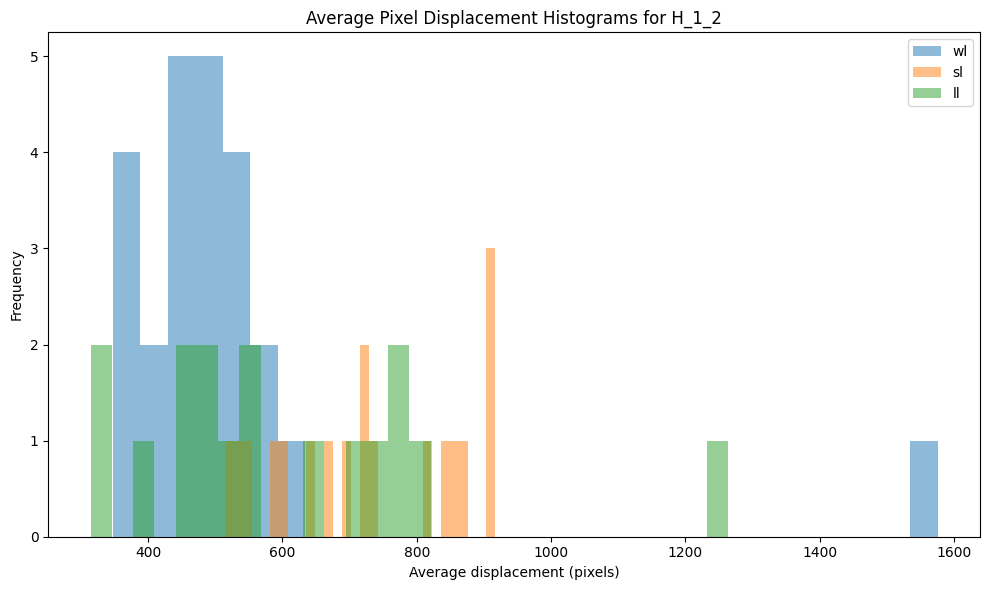

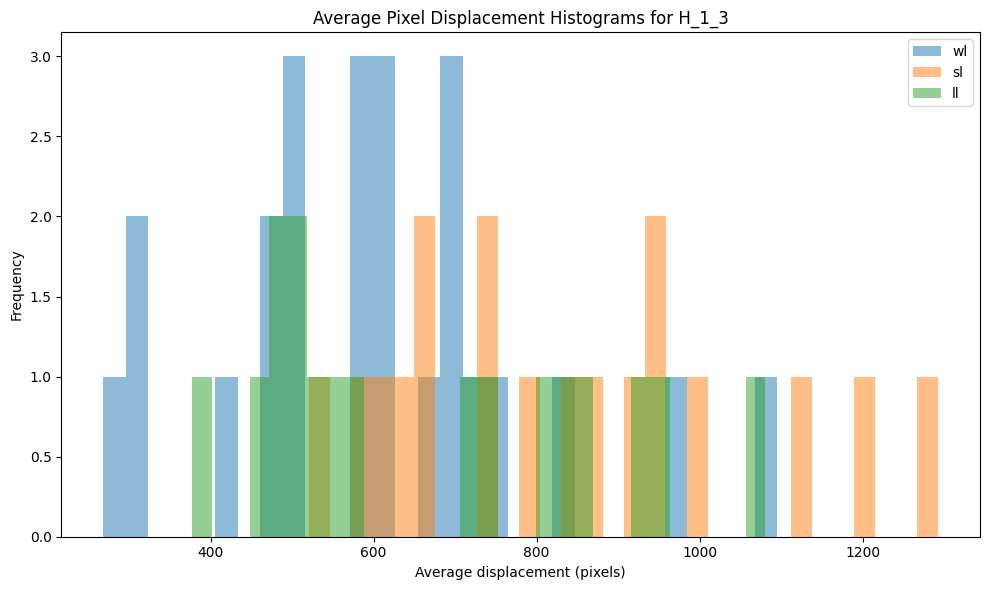

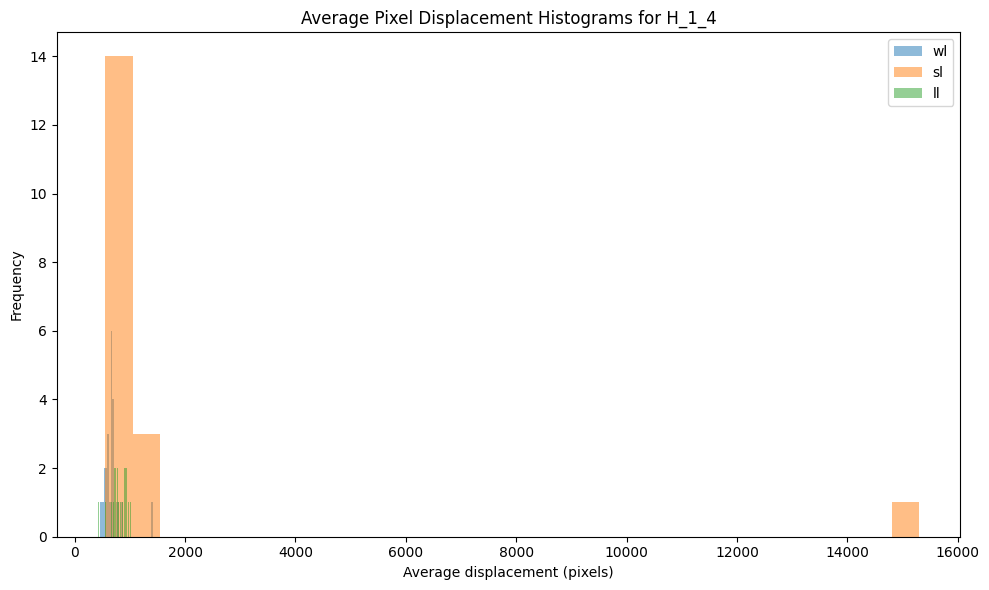

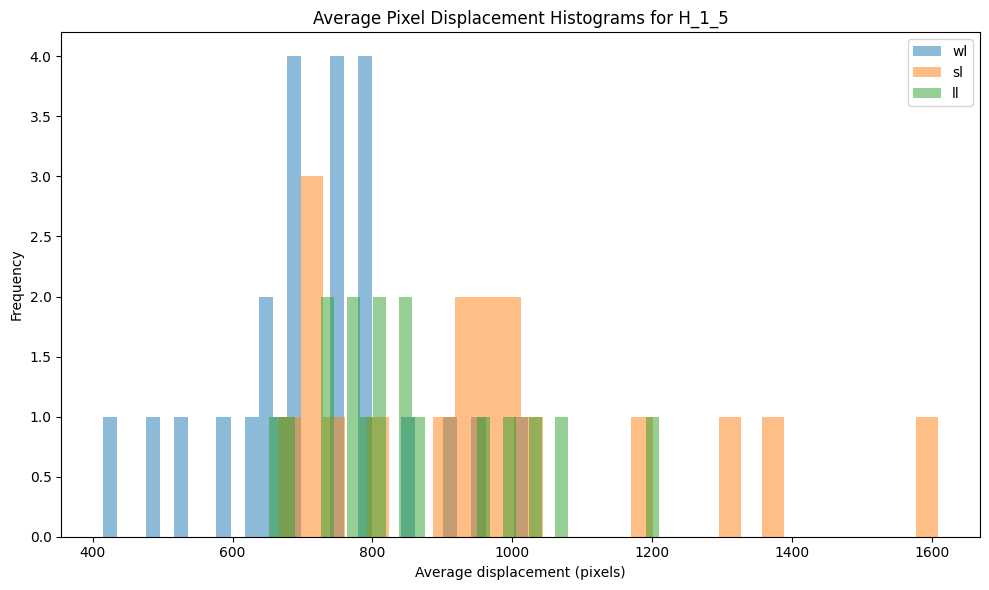

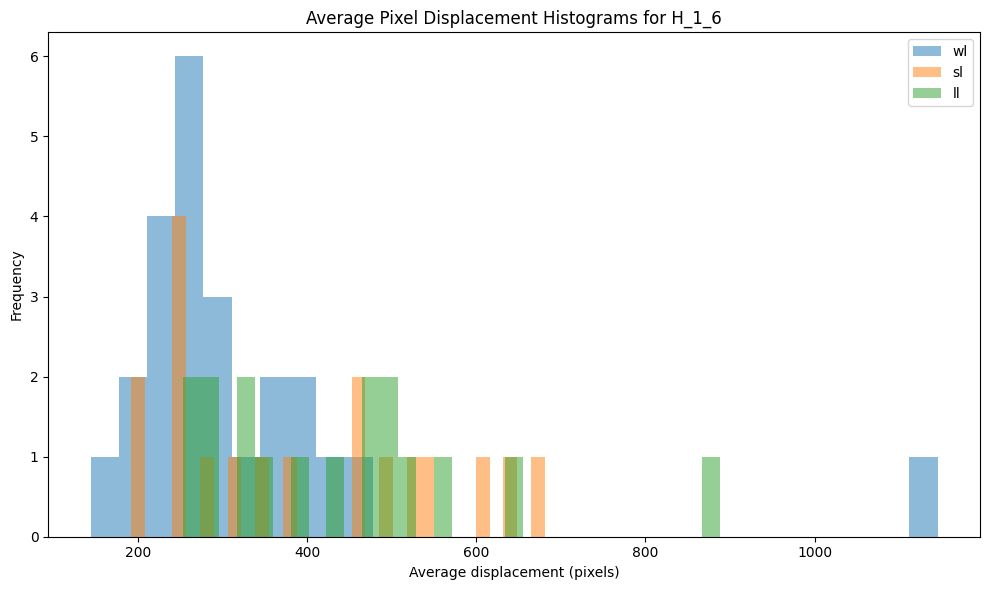

In [11]:
# Plotting displacement histograms with new disp_stats structure
for hfile in H_FILES:
    plt.figure(figsize=(10, 6))
    plt.title(f"Average Pixel Displacement Histograms for {hfile}")
    plt.xlabel("Average displacement (pixels)")
    plt.ylabel("Frequency")

    for prefix in SEQ_PREFIXES:
        # Extract all displacement values for this hfile and prefix (dict values)
        data = list(disp_stats[hfile][prefix].values())
        if len(data) > 0:
            plt.hist(data, bins=30, alpha=0.5, label=prefix)

    plt.legend()
    plt.tight_layout()
    plt.show()


# Homo Decompose Stats

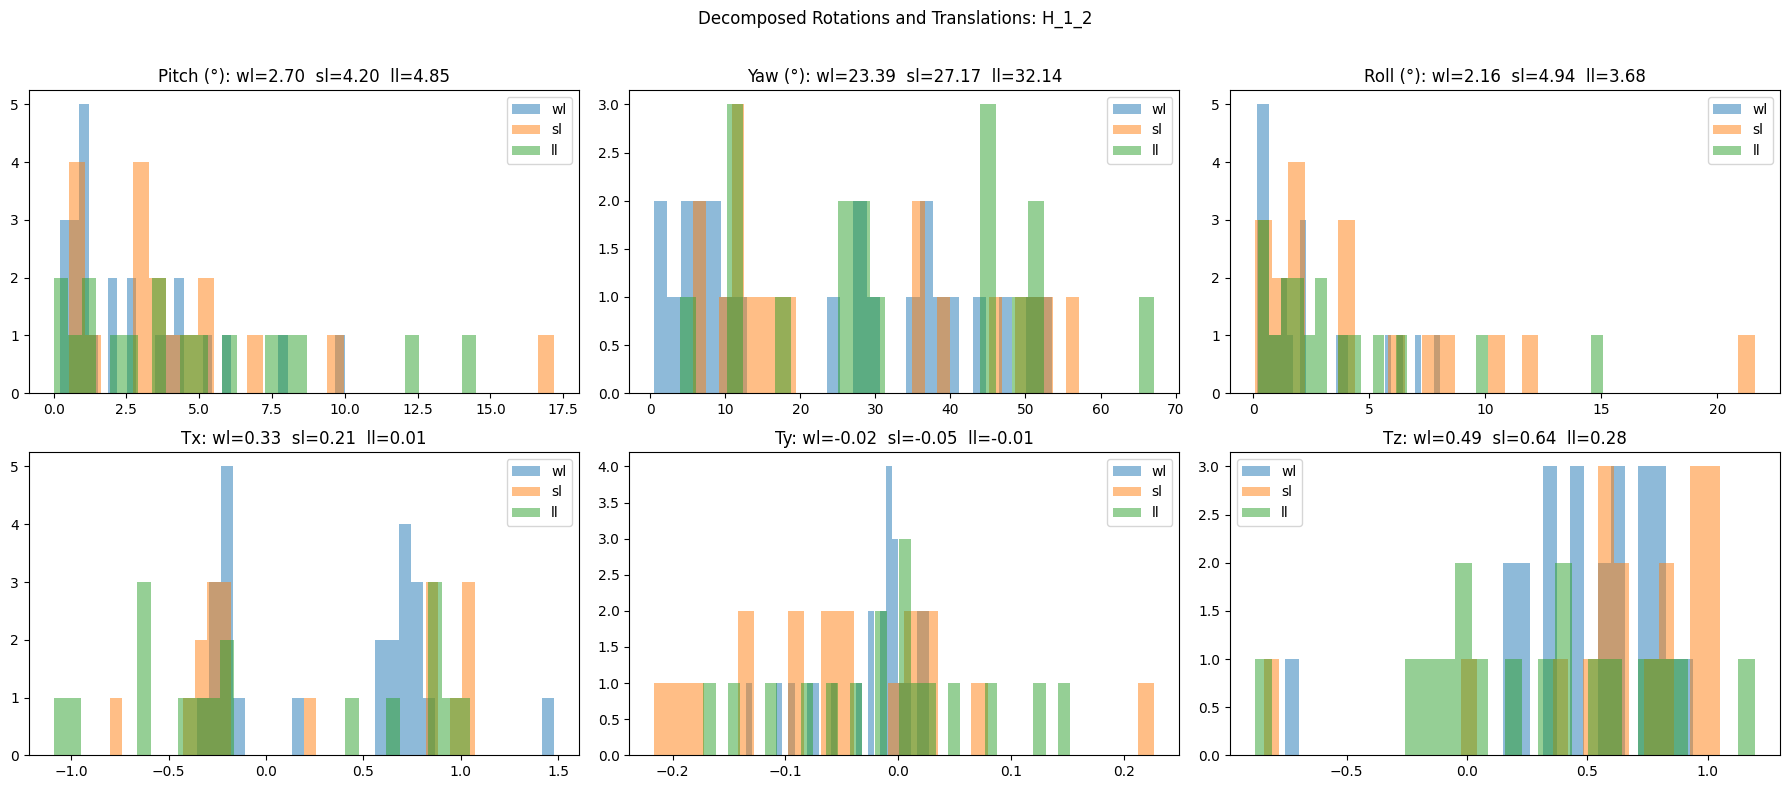

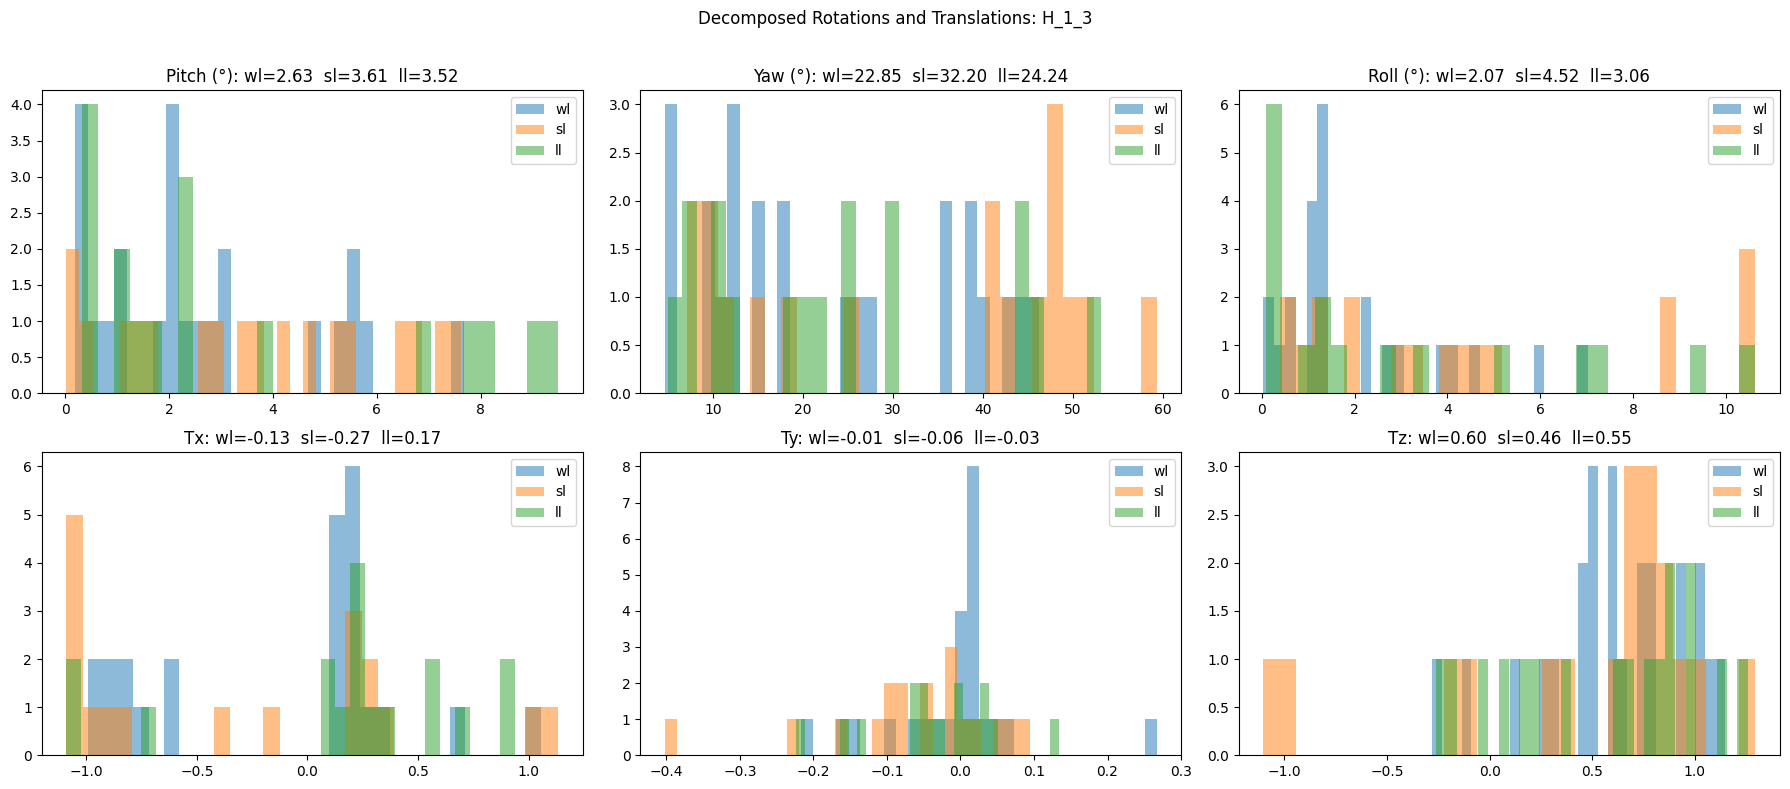

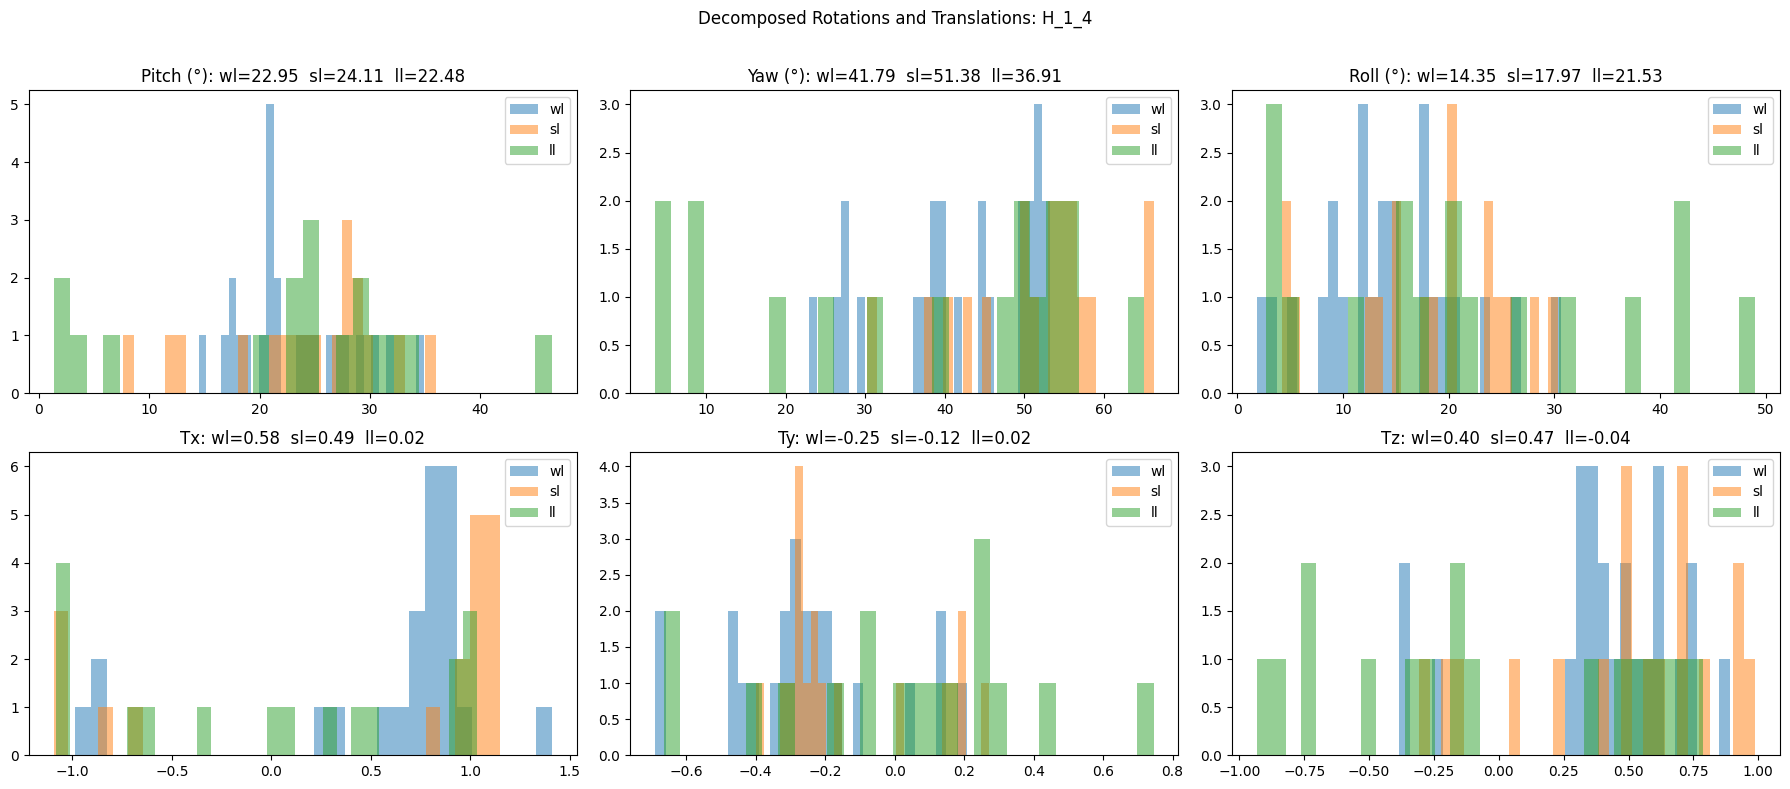

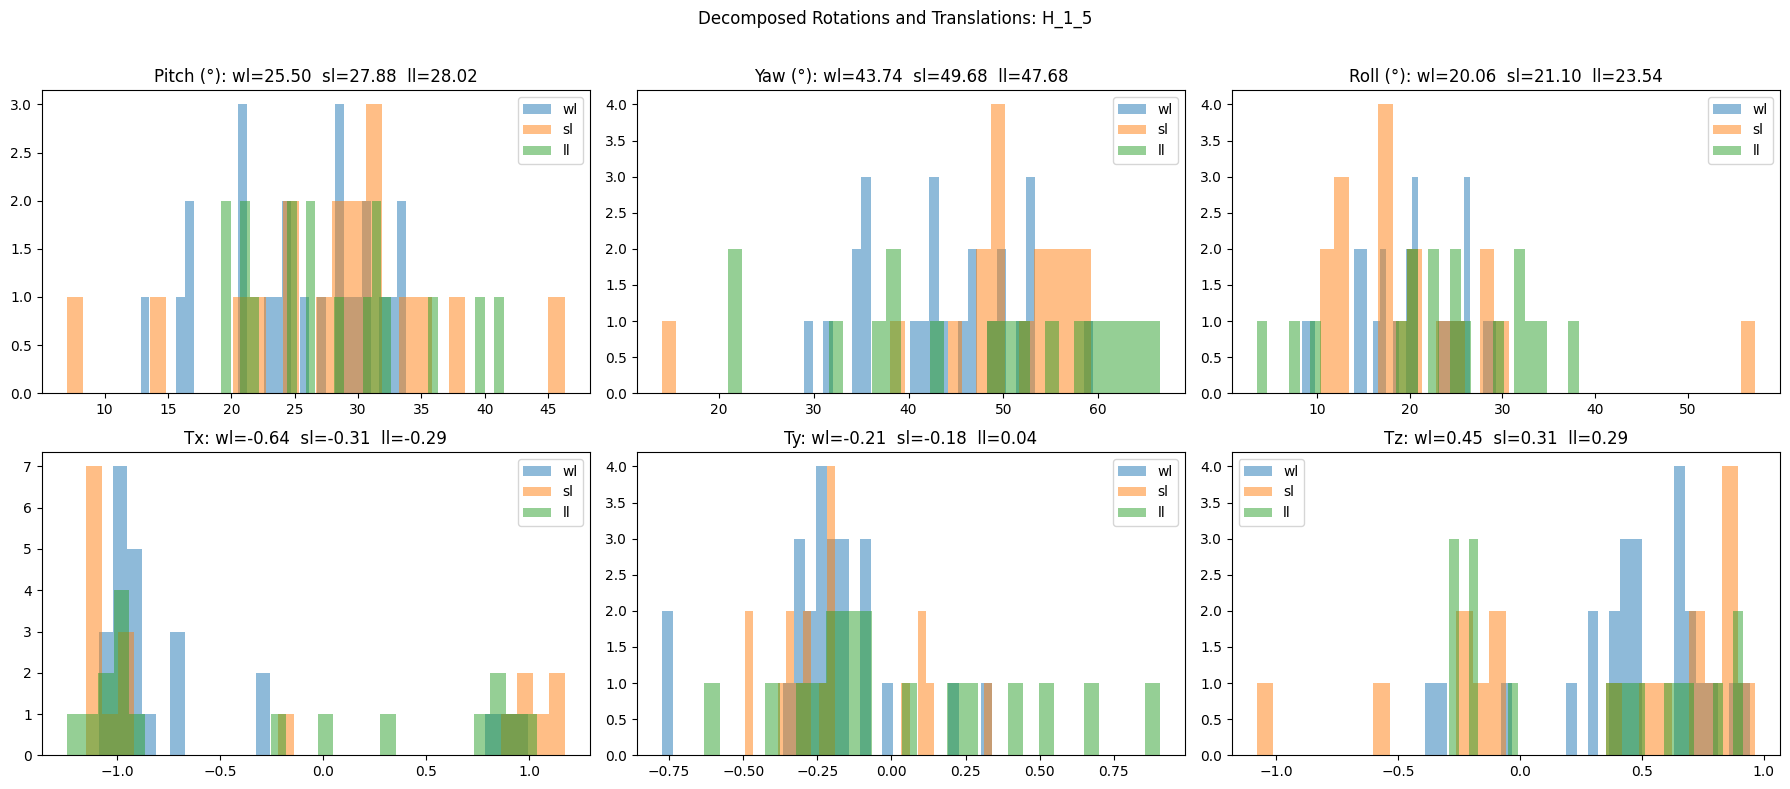

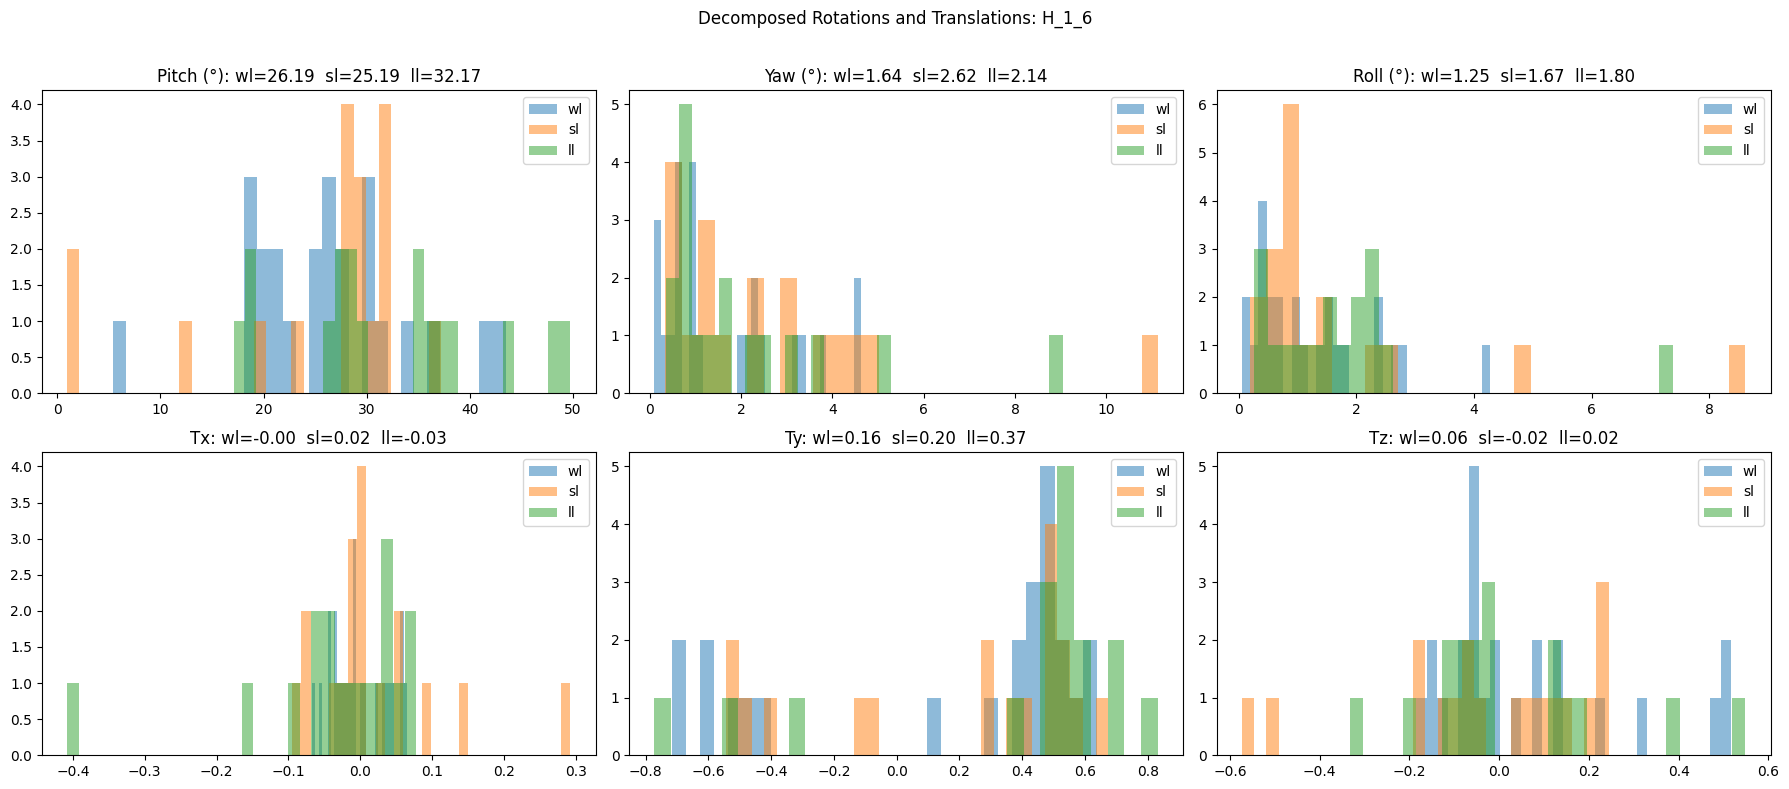

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from collections import defaultdict

# --- Configuration ---
HPATCHES_ROOT = "/home/boat/proxyISP/pytorch-superpoint/datasets/HPatches_s21fe_reordered"
H_FILES = ["H_1_2", "H_1_3", "H_1_4", "H_1_5", "H_1_6"]
SEQ_PREFIXES = ["wl", "sl", "ll"]
cam_param = np.load("/home/boat/proxyISP/ProxyOpt/camera_parameters/s21fe_main_3000x4000/CalibrationMatrix_college_cpt.npz")
K = cam_param["Camera_matrix"]
# dist = cam_param["distCoeff"]  # Placeholder values

# --- Helpers ---

def compute_homography(R, t, normal, d_inv, K):
    t = t.reshape(3, 1)
    normal = normal.reshape(3, 1)
    H_euclidean = R + d_inv * (t @ normal.T)
    H = K @ H_euclidean @ np.linalg.inv(K)
    H_euclidean /= H_euclidean[2, 2]
    H /= H[2, 2]
    return H, H_euclidean

def read_homography(file_path):
    with open(file_path, "r") as f:
        values = list(map(float, f.read().split()))
        return np.array(values).reshape(3, 3)

def rotation_matrix_to_euler_angles(R):
    # From OpenCV docs
    sy = np.sqrt(R[0,0] ** 2 + R[1,0] ** 2)
    singular = sy < 1e-6
    if not singular:
        x = np.arctan2(R[2,1], R[2,2])
        y = np.arctan2(-R[2,0], sy)
        z = np.arctan2(R[1,0], R[0,0])
    else:
        x = np.arctan2(-R[1,2], R[1,1])
        y = np.arctan2(-R[2,0], sy)
        z = 0
    return np.degrees([x, y, z])  # pitch, yaw, roll

# --- Storage ---
stats = {
    hfile: {prefix: {"rot": [], "trans": []} for prefix in SEQ_PREFIXES}
    for hfile in H_FILES
}

# --- Processing ---
for seq in os.listdir(HPATCHES_ROOT):
    seq_path = os.path.join(HPATCHES_ROOT, seq)
    if not os.path.isdir(seq_path):
        continue
    prefix = next((p for p in SEQ_PREFIXES if seq.startswith(p)), None)
    if prefix is None:
        continue

    for hfile in H_FILES:
        hpath = os.path.join(seq_path, hfile)
        if not os.path.exists(hpath):
            continue

        try:
            H = read_homography(hpath)
            H = H / H[2, 2]

            # Decompose homography
            num, Rs, Ts, normals = cv2.decomposeHomographyMat(H, K)

            for i in range(num):
                R = Rs[i]
                T = Ts[i].flatten()
                n = normals[i].flatten()

                # Optional: assume plane at 1m → d_inv = 1.0
                d_inv = 1.0

                # Reconstruct homography (not used for stat, but useful to validate)
                H_recon, H_euclid = compute_homography(R, T, n, d_inv, K)

                # Convert rotation to Euler
                euler = rotation_matrix_to_euler_angles(R)
                euler = np.abs(euler)

                stats[hfile][prefix]["rot"].append(euler)
                stats[hfile][prefix]["trans"].append(T)

                # Only collect first decomposition for each case
                break

        except Exception as e:
            print(f"Error processing {hpath}: {e}")

# --- Plotting ---
for hfile in H_FILES:
    fig, axs = plt.subplots(2, 3, figsize=(18, 8))
    fig.suptitle(f"Decomposed Rotations and Translations: {hfile}")

    labels = ["Pitch (°)", "Yaw (°)", "Roll (°)", "Tx", "Ty", "Tz"]

    # Rotations
    for i in range(3):
        title_with_means = f"{labels[i]}: "
        for prefix in SEQ_PREFIXES:
            data = np.array(stats[hfile][prefix]["rot"])
            if len(data) > 0:
                axs[0, i].hist(data[:, i], bins=30, alpha=0.5, label=prefix)
                mean_val = np.mean(data[:, i])
                title_with_means += f"{prefix}={mean_val:.2f}  "
        axs[0, i].set_title(title_with_means.strip())
        axs[0, i].legend()

    # Translations
    for i in range(3):
        title_with_means = f"{labels[i+3]}: "
        for prefix in SEQ_PREFIXES:
            data = np.array(stats[hfile][prefix]["trans"])
            if len(data) > 0:
                axs[1, i].hist(data[:, i], bins=30, alpha=0.5, label=prefix)
                mean_val = np.mean(data[:, i])
                title_with_means += f"{prefix}={mean_val:.2f}  "
        axs[1, i].set_title(title_with_means.strip())
        axs[1, i].legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()



In [2]:
import pandas as pd

# === Collect stats to Pandas DataFrame ===
records = []
# --- Processing ---
records = []

for seq in os.listdir(HPATCHES_ROOT):
    seq_path = os.path.join(HPATCHES_ROOT, seq)
    if not os.path.isdir(seq_path):
        continue
    prefix = next((p for p in SEQ_PREFIXES if seq.startswith(p)), None)
    if prefix is None:
        continue

    for hfile in H_FILES:
        hpath = os.path.join(seq_path, hfile)
        if not os.path.exists(hpath):
            continue

        try:
            H = read_homography(hpath)
            H = H / H[2, 2]

            # Decompose homography
            num, Rs, Ts, normals = cv2.decomposeHomographyMat(H, K)

            for i in range(num):
                R = Rs[i]
                T = Ts[i].flatten()
                n = normals[i].flatten()

                euler = rotation_matrix_to_euler_angles(R)
                euler = np.abs(euler)

                records.append({
                    "sequence": seq,
                    "H_file": hfile,
                    "solution_id": i,
                    "rotx": round(euler[0], 3),
                    "roty": round(euler[1], 3),
                    "rotz": round(euler[2], 3),
                    "transx": round(T[0], 3),
                    "transy": round(T[1], 3),
                    "transz": round(T[2], 3)
                })

        except Exception as e:
            print(f"Error processing {hpath}: {e}")

df = pd.DataFrame.from_records(records)

print("\n=== Per-sequence Homography Stats ===")
df = df.sort_values(by="sequence")
df = df[df["H_file"] == "H_1_2"]
print(df.to_string(index=False))


=== Per-sequence Homography Stats ===
             sequence H_file  solution_id   rotx   roty   rotz  transx  transy  transz
     ll-chinesefamily  H_1_2            0  2.270 50.618  0.200  -0.966   0.030  -0.220
     ll-chinesefamily  H_1_2            1  2.270 50.618  0.200   0.966  -0.030   0.220
     ll-chinesefamily  H_1_2            2  0.678  8.233  0.869  -0.340   0.017   0.930
     ll-chinesefamily  H_1_2            3  0.678  8.233  0.869   0.340  -0.017  -0.930
         ll_abstract1  H_1_2            2  1.008  1.588  1.076  -0.093  -0.029   0.421
         ll_abstract1  H_1_2            3  1.008  1.588  1.076   0.093   0.029  -0.421
         ll_abstract1  H_1_2            0  1.444 26.102  3.016  -0.432   0.009  -0.018
         ll_abstract1  H_1_2            1  1.444 26.102  3.016   0.432  -0.009   0.018
  ll_agrirobotwallart  H_1_2            3  4.537 55.685  5.025  -1.050   0.008  -0.678
  ll_agrirobotwallart  H_1_2            2  4.537 55.685  5.025   1.050  -0.008   0.678
  ll